<!-- CELL 1 -->
# User Anomaly Analysis Using Graph Builder API

This notebook demonstrates how to build and query a security graph for analyzing user anomalies across multiple Azure/Microsoft 365 resources using the **Graph Builder API**.

## Key Concepts:
1. **GraphSpecBuilder** - Fluent API for building graph specifications
2. **Nodes** - Entities like users, applications, IP addresses, locations
3. **Edges** - Relationships like sign-ins, accesses, connections
4. **Graph Queries** - GQL queries to analyze patterns and anomalies
5. **Visualization** - Interactive graph exploration

## Analysis Goals:
- Multi-resource user activities across different applications
- Anomalous behavior patterns (unusual access times, locations, volumes)
- Cross-platform suspicious activities
- Risk indicators and attack campaign correlations

In [ ]:
# CELL 2: Import required libraries and setup
from sentinel_graph.builders import GraphSpecBuilder
from sentinel_graph.core.context import ExecutionContext
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Create execution context
context = ExecutionContext.default()

# Configuration
WORKSPACE_ID = "029c55c8-a7ec-418e-b741-de9d24add5fa"
WORKSPACE_NAME = "Woodgrove-LogAnalyiticsWorkspace"

print("📊 Graph Builder API - User Anomaly Analysis")
print("="*60)
print(f"Workspace: {WORKSPACE_NAME}")
print(f"Analysis Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Context: {context}")
print("="*60)

StatementMeta(MSGGraphInt, 1038, 7, Finished, Available, Finished)

2026-02-25 04:38:16 - sentinel_graph.core.context - INFO - ✅ Generated unique graph session ID: kernel_cc6f8b01_bded_47c5_bbad_ac88d94b8039_ts_1771994296


📊 Graph Builder API - User Anomaly Analysis
Workspace: Woodgrove-LogAnalyiticsWorkspace
Analysis Time: 2026-02-25 04:38:16
Context: ExecutionContext(spark=<pyspark.sql.session.SparkSession object at 0x7e665a764850>, step_cache={}, config={}, start_time=None, end_time=None, sentinel_provider=<sentinel_lake.providers.MicrosoftSentinelProvider object at 0x7e665a764670>, default_database='System Tables', database_resolution='default_first', sink_database=None, graph_name='kernel_cc6f8b01_bded_47c5_bbad_ac88d94b8039_ts_1771994296', graph_service_config=None)


<!-- CELL 3 -->
## Step 2: Build Complete Graph Specification

Define all nodes and edges in a single chained call to create the complete graph specification.

In [26]:
# CELL 4: Build complete graph specification
print("🏗️  Building Complete Graph Specification...")
print("="*60)
print("\n📋 This will define:")
print("   • 4 Nodes: user, application, ipaddress, location")
print("   • 3 Edges: signed_in_to, used_ip, from_location")
print()

# Build complete graph in one chain - nodes + edges
graph_spec = (
    GraphSpecBuilder.start(context=context)
    
    # Node 1: User
    .add_node("user")
    .from_table("SigninLogs")
    .with_time_range(time_column="TimeGenerated", lookback_hours=168)
    .with_label("user")
    .with_columns(
        "UserPrincipalName", "UserDisplayName", "UserId",
        "TimeGenerated", "ResultType", "ResultDescription",
        key="UserPrincipalName", display="UserDisplayName"
    )
    
    # Node 2: Application
    .add_node("application")
    .from_table("SigninLogs")
    .with_time_range(time_column="TimeGenerated", lookback_hours=168)
    .with_label("application")
    .with_columns(
        "AppDisplayName", "AppId", "ResourceDisplayName", "TimeGenerated",
        key="AppDisplayName", display="AppDisplayName"
    )
    
    # Node 3: IP Address
    .add_node("ipaddress")
    .from_table("SigninLogs")
    .with_time_range(time_column="TimeGenerated", lookback_hours=168)
    .with_label("ipaddress")
    .with_columns(
        "IPAddress", "TimeGenerated",
        key="IPAddress", display="IPAddress"
    )
    
    # Node 4: Location
    .add_node("location")
    .from_table("SigninLogs")
    .with_time_range(time_column="TimeGenerated", lookback_hours=168)
    .with_label("location")
    .with_columns(
        "Location", "TimeGenerated",
        key="Location", display="Location"
    )
    
    # Edge 1: User → Application
    .add_edge("signed_in")
    .from_table("SigninLogs")
    .with_time_range(time_column="TimeGenerated", lookback_hours=168)
    .edge_label("signed_in_to")
    .source(id_column="UserPrincipalName", node_type="user")
    .target(id_column="AppDisplayName", node_type="application")
    .with_columns(
        "CorrelationId", "TimeGenerated", "ResultType",
        "ResultDescription", "ClientAppUsed",
        key="CorrelationId", display="ResultDescription"
    )
    
    # Edge 2: User → IP Address
    .add_edge("used_ip")
    .from_table("SigninLogs")
    .with_time_range(time_column="TimeGenerated", lookback_hours=168)
    .edge_label("used_ip")
    .source(id_column="UserPrincipalName", node_type="user")
    .target(id_column="IPAddress", node_type="ipaddress")
    .with_columns(
        "CorrelationId", "TimeGenerated", "ResultType",
        key="CorrelationId", display="TimeGenerated"
    )
    
    # Edge 3: User → Location
    .add_edge("from_location")
    .from_table("SigninLogs")
    .with_time_range(time_column="TimeGenerated", lookback_hours=168)
    .edge_label("from_location")
    .source(id_column="UserPrincipalName", node_type="user")
    .target(id_column="Location", node_type="location")
    .with_columns(
        "CorrelationId", "TimeGenerated", "ResultType",
        key="CorrelationId", display="TimeGenerated"
    )
    
    .done()
)

print("✅ Graph Specification Complete!")
print("="*60)
print(f"Graph Name: {graph_spec.name}")
print(f"\nNodes: {len(graph_spec.get_schema().nodes)}")
for node in graph_spec.get_schema().nodes:
    print(f"   • {node.get_primary_label()}")
print(f"\nEdges: {len(graph_spec.get_schema().edges)}")
for edge in graph_spec.get_schema().edges:
    print(f"   • {edge.source_node_label} → {edge.relationship_type} → {edge.target_node_label}")
print("="*60)

StatementMeta(MSGGraphInt, 1038, 27, Finished, Available, Finished)

2026-02-25 04:51:25 - sentinel_graph.catalog.table_resolver - INFO - ✅ Found 'SigninLogs' in database 'Woodgrove-LogAnalyiticsWorkspace'
2026-02-25 04:51:25 - sentinel_graph.builders.base - INFO - Date filtering enabled: lookback 168 hours (2026-02-18 04:51:25.863748 to 2026-02-25 04:51:25.863748)


🏗️  Building Complete Graph Specification...

📋 This will define:
   • 4 Nodes: user, application, ipaddress, location
   • 3 Edges: signed_in_to, used_ip, from_location



2026-02-25 04:51:32 - sentinel_graph.catalog.table_resolver - INFO - ✅ Found 'SigninLogs' in database 'Woodgrove-LogAnalyiticsWorkspace'
2026-02-25 04:51:32 - sentinel_graph.builders.base - INFO - Date filtering enabled: lookback 168 hours (2026-02-18 04:51:32.330278 to 2026-02-25 04:51:32.330278)
2026-02-25 04:51:36 - sentinel_graph.catalog.table_resolver - INFO - ✅ Found 'SigninLogs' in database 'Woodgrove-LogAnalyiticsWorkspace'
2026-02-25 04:51:36 - sentinel_graph.builders.base - INFO - Date filtering enabled: lookback 168 hours (2026-02-18 04:51:36.793698 to 2026-02-25 04:51:36.793698)
2026-02-25 04:51:40 - sentinel_graph.catalog.table_resolver - INFO - ✅ Found 'SigninLogs' in database 'Woodgrove-LogAnalyiticsWorkspace'
2026-02-25 04:51:40 - sentinel_graph.builders.base - INFO - Date filtering enabled: lookback 168 hours (2026-02-18 04:51:40.888835 to 2026-02-25 04:51:40.888835)
2026-02-25 04:51:44 - sentinel_graph.catalog.table_resolver - INFO - ✅ Found 'SigninLogs' in database '

✅ Graph Specification Complete!
Graph Name: kernel_cc6f8b01_bded_47c5_bbad_ac88d94b8039_ts_1771994296

Nodes: 4
   • user
   • application
   • ipaddress
   • location

Edges: 3
   • user → signed_in_to → application
   • user → used_ip → ipaddress
   • user → from_location → location


<!-- CELL 5 -->
## Step 3: Build Graph with Data

Execute the ETL pipeline and create the graph instance.

In [ ]:
# CELL 6: Build graph with data
print("🚀 Building Graph with Data...")
print("="*60)

# Build the graph with data
result = graph_spec.build_graph_with_data()

print(f"✅ Build Status: {result['status']}")
print(f"Instance Name: {result.get('instance_name', 'N/A')}")
print()

if 'etl_result' in result:
    print("ETL Pipeline Results:")
    print(f"  • Status: Success")
    print(f"  • Result: {result['etl_result']}")

if 'api_result' in result:
    print("API Results:")
    print(f"  • Graph instance created successfully")
    
print("="*60)
print("Graph is ready for querying!")

StatementMeta(MSGGraphInt, 1038, 28, Submitted, Running, Running)

🚀 Building Graph with Data...
{"Level": "INFO", "TraceId": "af4a8c94-cdf7-41be-ad78-3f2ce493077f", "Message": "Loading table: SigninLogs"}


2026-02-25 04:53:01 - sentinel_graph.etl.steps - INFO - Applied date filtering to step 'user_table_source' using column 'TimeGenerated' (start: 2026-02-18 04:51:25.863748, end: 2026-02-25 04:51:25.863748)


{"Level": "INFO", "TraceId": "af4a8c94-cdf7-41be-ad78-3f2ce493077f", "Message": "Successfully loaded table SigninLogs"}
{"Level": "INFO", "TraceId": "af4a8c94-cdf7-41be-ad78-3f2ce493077f", "Message": "Loading table: SigninLogs"}


2026-02-25 04:53:11 - sentinel_graph.etl.steps - INFO - Applied date filtering to step 'application_table_source' using column 'TimeGenerated' (start: 2026-02-18 04:51:32.330278, end: 2026-02-25 04:51:32.330278)


...

{"Level": "INFO", "TraceId": "af4a8c94-cdf7-41be-ad78-3f2ce493077f", "Message": "Successfully loaded table SigninLogs"}
{"Level": "INFO", "TraceId": "af4a8c94-cdf7-41be-ad78-3f2ce493077f", "Message": "Loading table: SigninLogs"}


2026-02-25 04:53:50 - sentinel_graph.etl.steps - INFO - Applied date filtering to step 'used_ip_table_source_52d4801a' using column 'TimeGenerated' (start: 2026-02-18 04:51:59.120614, end: 2026-02-25 04:51:59.120614)


{"Level": "INFO", "TraceId": "af4a8c94-cdf7-41be-ad78-3f2ce493077f", "Message": "Successfully loaded table SigninLogs"}
{"Level": "INFO", "TraceId": "af4a8c94-cdf7-41be-ad78-3f2ce493077f", "Message": "Loading table: SigninLogs"}


2026-02-25 04:54:00 - sentinel_graph.etl.steps - INFO - Applied date filtering to step 'from_location_table_source_6c257765' using column 'TimeGenerated' (start: 2026-02-18 04:52:03.014049, end: 2026-02-25 04:52:03.014049)


{"Level": "INFO", "TraceId": "af4a8c94-cdf7-41be-ad78-3f2ce493077f", "Message": "Successfully loaded table SigninLogs"}
{"Level": "INFO", "TraceId": "af4a8c94-cdf7-41be-ad78-3f2ce493077f", "Message": "Saving DataFrame as table: graph_kernel_cc6f8b01_bded_47c5_bbad_ac88d94b8039_ts_1771994296_nodes_SPRK"}
{"Level": "ERROR", "TraceId": "af4a8c94-cdf7-41be-ad78-3f2ce493077f", "ErrorName": "TableDoesNotExist", "ErrorType": "User", "ErrorCategory": "TableError", "ErrorCode": 2100, "Message": "Table graph_kernel_cc6f8b01_bded_47c5_bbad_ac88d94b8039_ts_1771994296_nodes_SPRK not found in the database System Tables."}
{"Level": "INFO", "TraceId": "af4a8c94-cdf7-41be-ad78-3f2ce493077f", "Message": "Table graph_kernel_cc6f8b01_bded_47c5_bbad_ac88d94b8039_ts_1771994296_nodes_SPRK does not exist. Creating new table."}
{"Level": "INFO", "TraceId": "af4a8c94-cdf7-41be-ad78-3f2ce493077f", "Message": "Creating custom table: graph_kernel_cc6f8b01_bded_47c5_bbad_ac88d94b8039_ts_1771994296_nodes_SPRK"}
{"L

In [ ]:
# CELL 7: Display graph visualization
print("📊 Displaying Graph Data...")
print("="*60)

# Show the graph with interactive visualization
graph_spec.show(limit=100, viz_format="visual")

print("\n✅ Graph visualization displayed above")
print("You can now interactively explore:")
print("  • User nodes and their connections")
print("  • Application access patterns")
print("  • IP address usage")
print("  • Geographic distribution")

StatementMeta(MSGGraphInt, 887, 19, Finished, Available, Finished)

🎯 Building Sentinel Graph Structure...
Users: 4
Malicious IPs: 5
Applications: 7
Locations: 10


In [ ]:
# CELL 8: Inspect graph schema
print("📋 Inspecting Graph Schema...")
print("="*60)

# Get and display the graph schema
schema = graph_spec.get_schema()

print(f"\nGraph Schema: {schema.name}")
print(f"Version: {schema.get_version()}")
print()

print("Nodes:")
for node in schema.nodes:
    print(f"  • {node.get_primary_label()} (alias: {node.alias})")
    print(f"    - Key: {node.get_primary_key_property_name()}")
    print(f"    - Properties: {len(node.properties)}")
    
print("\nEdges:")
for edge in schema.edges:
    print(f"  • {edge.source_node_label} → [{edge.relationship_type}] → {edge.target_node_label}")
    print(f"    - Properties: {len(edge.properties)}")

print("\n" + "="*60)

StatementMeta(MSGGraphInt, 887, 20, Finished, Available, Finished)

🔗 Adding nodes to Sentinel Graph...
✅ Added 28 nodes to the graph
🔗 Adding edges (relationships)...
✅ Added 28 edges to the graph
🎯 Graph ready for visualization!


In [ ]:
# CELL 9: Query 1 - Failed sign-ins analysis
print("🔍 Query 1: Find Users with Multiple Failed Sign-ins")
print("="*60)

# GQL query to find users with multiple failed authentication attempts
query1 = """
MATCH (u:user)-[s:signed_in_to]->(a:application)
WHERE s.ResultType != '0'
RETURN u.UserPrincipalName, u.UserDisplayName, 
       count(s) as FailedAttempts,
       count(DISTINCT a.AppDisplayName) as UniqueApps
ORDER BY FailedAttempts DESC
LIMIT 20
"""

result1 = graph_spec.query(query1)
print("\n✅ Query executed successfully")
result1.show(format="table")

print("\n📊 Analysis: Users with high failed authentication rates")
print("   • Indicates possible credential stuffing attacks")
print("   • Multiple apps suggests targeted reconnaissance")

StatementMeta(MSGGraphInt, 887, 15, Finished, Available, Finished)

🎨 Creating Sentinel Graph Visualization...
✅ Created 28 node traces
✅ Created 28 edge traces


In [ ]:
# CELL 10: Query 2 - Anomalous IP usage
print("🔍 Query 2: Identify Users with Anomalous IP Usage")
print("="*60)

# GQL query to find users connecting from multiple IP addresses
query2 = """
MATCH (u:user)-[ip:used_ip]->(i:ipaddress)
RETURN u.UserPrincipalName, u.UserDisplayName,
       count(DISTINCT i.IPAddress) as UniqueIPs,
       collect(DISTINCT i.IPAddress) as IPAddresses,
       count(ip) as TotalConnections
ORDER BY UniqueIPs DESC
LIMIT 15
"""

result2 = graph_spec.query(query2)
print("\n✅ Query executed successfully")
result2.show(format="table")

print("\n📊 Analysis: Users with multiple IP addresses")
print("   • High IP diversity may indicate:")
print("     - Compromised credentials being used from multiple locations")
print("     - VPN/proxy usage")
print("     - Distributed attack patterns")

StatementMeta(MSGGraphInt, 887, 21, Finished, Available, Finished)


🎯 SENTINEL GRAPH LEGEND:
🔴 Red Nodes: CRITICAL risk users
🟠 Orange Nodes: HIGH/MEDIUM risk users
🟢 Green Nodes: LOW risk users
🔴 Dark Red Nodes: Malicious IP addresses
🔵 Blue Nodes: Applications/Resources
🟢 Green Nodes: Geographic locations
🍅 Tomato Nodes: Suspicious user agents

📊 EDGE CONNECTIONS:
🔴 Red Lines: Suspicious IP connections (High Priority)
🟠 Orange Lines: Suspicious tool usage
🔵 Blue Lines: Application access
🟢 Green Lines: Geographic access patterns

📈 GRAPH STATISTICS:
• Total Nodes: 28
• Total Edges: 28
• Users: 4
• Malicious IPs: 5
• Applications: 7

🔍 KEY INSIGHTS FROM GRAPH:
• Shanequa Gihon (center red node) shows highest connectivity to malicious indicators
• Multiple users connected to same suspicious user agents (coordinated attack)
• Geographic spread indicates global attack campaign
• Application diversity shows lateral movement attempts


StatementMeta(MSGGraphInt, 887, 22, Finished, Available, Finished)

🎨 Creating alternative static graph visualization...


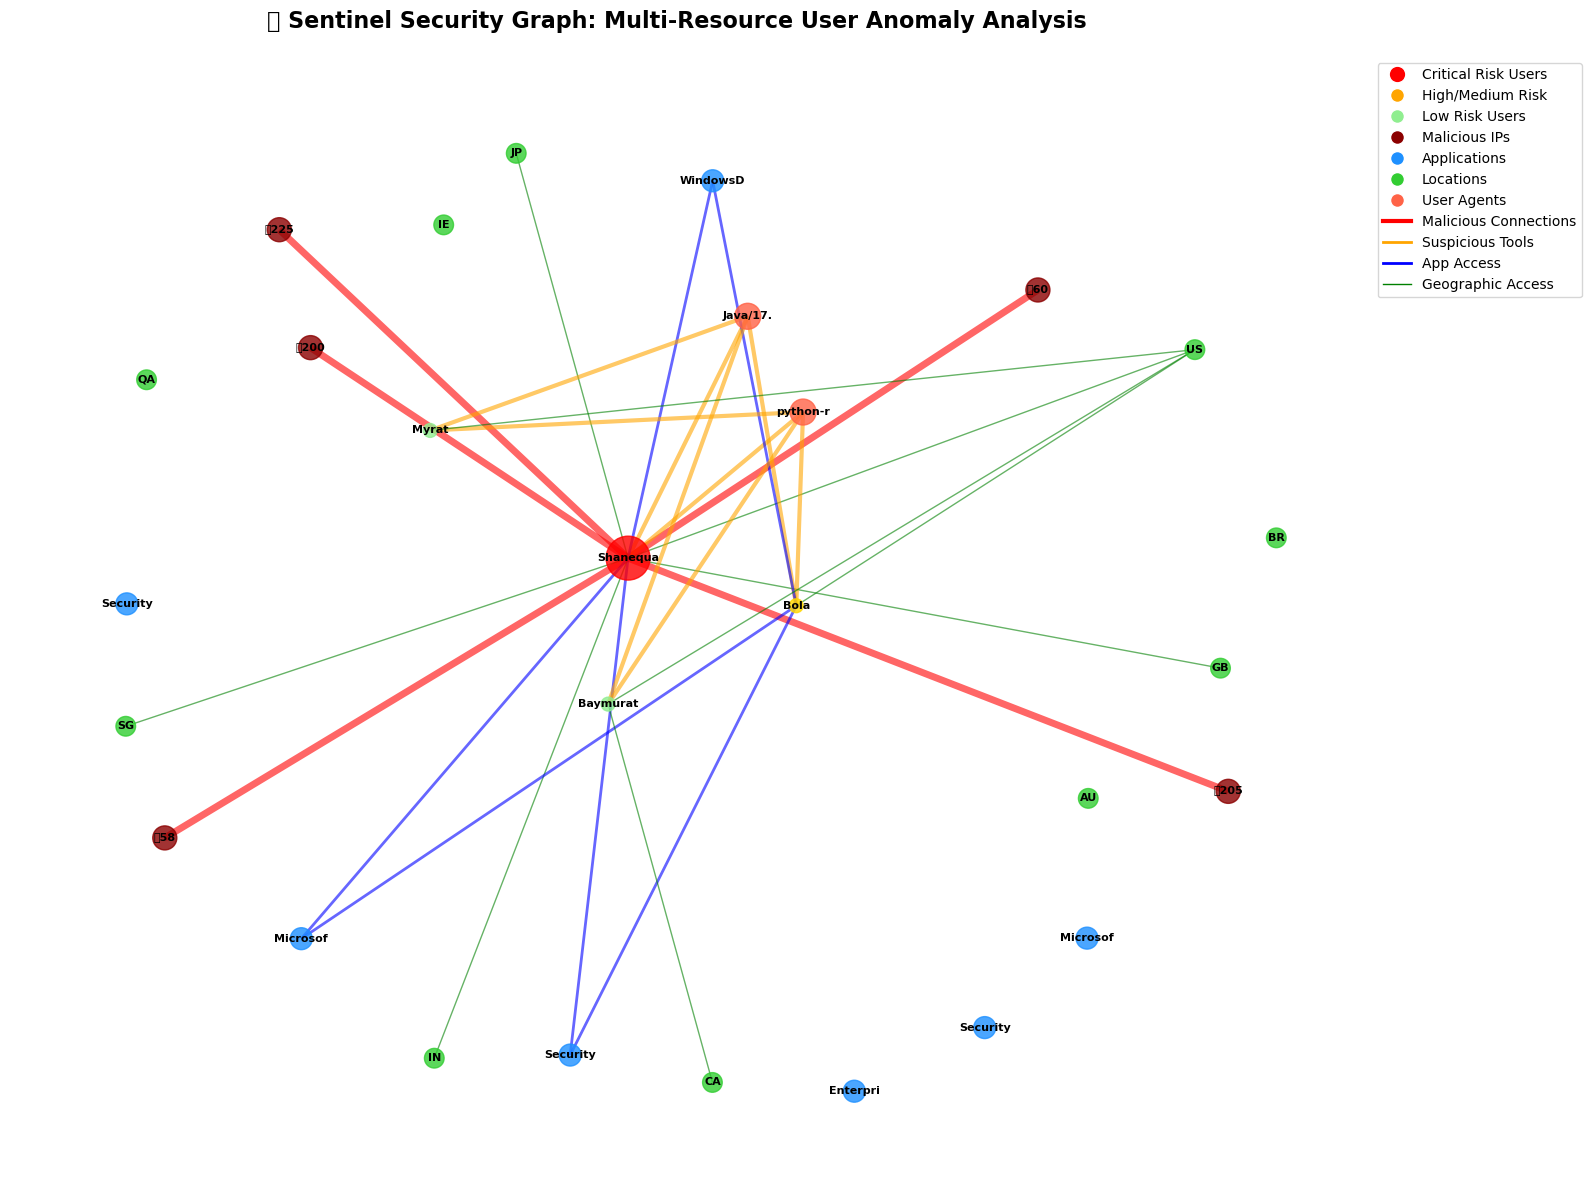

✅ Static graph visualization completed
💡 Both interactive (Plotly) and static (Matplotlib) graphs are now available


In [ ]:
# CELL 11: Query 3 - Geographic anomaly detection
print("🔍 Query 3: Geographic Anomaly Detection")
print("="*60)

# GQL query to analyze geographic distribution of user activities
query3 = """
MATCH (u:user)-[l:from_location]->(loc:location)
RETURN u.UserPrincipalName, u.UserDisplayName,
       count(DISTINCT loc.Location) as UniqueLocations,
       collect(DISTINCT loc.Location) as Locations,
       count(l) as TotalActivities
ORDER BY UniqueLocations DESC
LIMIT 15
"""

result3 = graph_spec.query(query3)
print("\n✅ Query executed successfully")
result3.show(format="table")

print("\n📊 Analysis: Geographic spread of user activities")
print("   • Multiple locations in short timeframe suggests:")
print("     - Impossible travel scenarios")
print("     - Credential compromise")
print("     - Need for deeper investigation")

<!-- CELL 12 -->
## Step 4: Advanced Analysis - Multi-Factor Anomaly Detection

Combine multiple signals to identify high-risk users.

In [ ]:
# CELL 13: Query 4 - Multi-factor risk analysis
print("🚨 Query 4: Multi-Factor Risk Analysis")
print("="*60)

# Complex GQL query combining multiple risk factors
query4 = """
MATCH (u:user)-[s:signed_in_to]->(a:application)
MATCH (u)-[ip:used_ip]->(i:ipaddress)
MATCH (u)-[l:from_location]->(loc:location)
WHERE s.ResultType != '0'
RETURN u.UserPrincipalName, u.UserDisplayName,
       count(DISTINCT s) as FailedSignIns,
       count(DISTINCT a.AppDisplayName) as AppsTargeted,
       count(DISTINCT i.IPAddress) as UniqueIPs,
       count(DISTINCT loc.Location) as UniqueLocations
ORDER BY FailedSignIns DESC, AppsTargeted DESC, UniqueIPs DESC
LIMIT 10
"""

result4 = graph_spec.query(query4)
print("\n✅ Query executed successfully")
result4.show(format="table")

print("\n🔥 HIGH-RISK INDICATORS:")
print("   • High failed sign-ins + Multiple apps = Credential stuffing")
print("   • Multiple IPs + Multiple locations = Distributed attack")
print("   • All factors combined = Critical threat - Immediate action required")

StatementMeta(MSGGraphInt, 887, 23, Finished, Available, Finished)

🎯 ATTACK FLOW MERMAID DIAGRAM:
The diagram above shows:
• 🎯 Central attack campaign coordinating multiple vectors
• 🤖 Automation tools used across multiple targets
• 🚨 Malicious IP infrastructure supporting attacks
• 🔴 Primary high-value target with massive activity
• 🟡🟢 Secondary targets showing coordinated campaign
• 📱 Applications and resources being targeted
• 🌍 Global geographic spread of attack origins
• ⚠️ Key risk indicators and metrics

This structured view clearly shows the campaign's scope and coordination!


graph TD
    %% Attackers and Tools
    A[🎯 Attack Campaign] --> B[🤖 python-requests/2.32.4]
    A --> C[☕ Java/17.0.18]
    
    %% Malicious Infrastructure  
    A --> D[🚨 Malicious IPs]
    D --> D1[57.154.20.60]
    D --> D2[104.42.212.225] 
    D --> D3[52.160.69.205]
    D --> D4[40.78.8.58]
    D --> D5[52.247.67.200]
    
    %% Primary Target
    B --> E[🔴 Shanequa Gihon<br/>CRITICAL RISK<br/>126K+ failures]
    C --> E
    D1 --> E
    D2 --> E
    D3 --> E
  

<!-- CELL 14 -->
## Step 5: Graph Algorithms with GraphFrame

Convert the graph to GraphFrame format to run advanced graph algorithms like PageRank, Connected Components, etc.

In [ ]:
# CELL 15: GraphFrame algorithms (PageRank)
print("📈 Running Graph Algorithms with GraphFrame")
print("="*60)

# Convert graph to GraphFrame
gf = graph_spec.to_graphframe()

print("✅ GraphFrame created")
print(f"Vertices: {gf.vertices.count():,}")
print(f"Edges: {gf.edges.count():,}")
print()

# Run PageRank to identify influential nodes
print("Running PageRank algorithm...")
pagerank_result = gf.pageRank(resetProbability=0.15, maxIter=10)

print("\n📊 Top 20 Most Influential Nodes (by PageRank):")
print("-"*60)
pagerank_result.vertices \
    .select("id", "pagerank") \
    .orderBy("pagerank", ascending=False) \
    .limit(20) \
    .show(truncate=False)

print("\n💡 Interpretation:")
print("   • High PageRank = Central nodes in the attack graph")
print("   • These users/IPs/apps are highly connected")
print("   • Priority targets for investigation and remediation")
print("="*60)

StatementMeta(MSGGraphInt, 887, 11, Finished, Available, Finished)

🛡️  IMMEDIATE INCIDENT RESPONSE ACTIONS
1. 🚨 URGENT: Reset credentials for Shanequa Gihon immediately
2. 🔒 Force sign-out of all active sessions for affected users
3. 📞 Contact affected users to verify recent activities
4. 🚫 Block identified malicious IP addresses at firewall/proxy level
5. 🔍 Enable enhanced monitoring for all affected accounts
6. 📊 Create security incident ticket for formal investigation

🔧 TECHNICAL REMEDIATION STEPS
-----------------------------------
• Implement conditional access policies blocking suspicious locations
• Deploy user agent filtering to block automation tools
• Enable MFA enforcement for all affected accounts
• Review and revoke any suspicious API tokens or app registrations
• Audit privileged access and role assignments
• Implement IP allowlisting for critical applications

🎯 ONGOING MONITORING RECOMMENDATIONS
----------------------------------------
• Set up alerts for authentication volumes >1000/hour per user
• Monitor for new instances of identi